# Object Detection

## Working with the datasets (https://universe.roboflow.com/orbit-final-project/flower-detection-fscsr and https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz)

### 1. Roboflow
After downloading, we made some data analysis using the check_dataset_class_split.py file, just to see that everything was downloaded as expected.

First of all, the main problem with this dataset was that one class was duplicate, so we first had to merge class indexed with 10 with the one indexed with 9 (see merge_9_10.py).

After that, we renamed the class 11-> 10 and 12-> 11, resulting in a total of 12 classes (index 0 to 11). See rename_11_12.py for more details.

Finally, test, val and train subsets were merged together manually, because we will redo these splits after the final merge with the second dataset.

### 2. Progetto-finale
This had no annotations, so we used the roboflow website to automatically create yolo segmentation boxes using a SAM model. We indexed the labels with 12 and 13, for us to be easier to concatanate this dataset to the roboflow dataset.

Then, we transformed the coco annotations generated from roboflow into a similar labels folder with yolo annotations, so we have yolo annotations in both the datasets (it is easier to have everything in yolo first and then transform to coco after we decide the splits, etc). The problem here was that the website did not let us to have directly yolo annotations, just coco annotations, so we had to transform coco to yolo first. See the file merge_coco_to_yolo.py for details.

### 3. Merging the 2
We manually merged the 2 big datasets and then did a 80/10/10 split (see the split_dataset.py file). After that, the same splits, with the same seeds were done for the coco format (as we've mentioned before, we decided what to do for yolo first, the for coco we do the same). See yolo_to_coco_split.py. We decided of these splits because the dataset has medium size and it is a standard in the literature.

Write a short dataset card in which you describe all the details of the dataset you will use (number of samples,
number of classes, dataset splits, annotation format etc.).

# 1. Yolo dataset (split_dataset)
- number of samples: 5157
- number of classes: 14 (indexed 0 - 13)
- dataset splits:
           - train (80% ; 3962 samples)
           - val (10% ; 600 samples)
           - test (10% ; 595 samples)

# 2. Coco dataset (coco_dataset)
- number of samples: 5157
- number of classes: 14 (indexed 0 - 13)
- dataset splits:
           - train (80% ; 3962 samples)
           - val (10% ; 600 samples)
           - test (10% ; 595 samples)

Create a chart showing the number of bounding boxes per class. This will immediately show class
imbalance.

In our PyCharm environment, we ran "bbox_class_chart.py" in every subfolder (train/test/val). I uploaded here just the images, to make the analysis here.

### Test subset

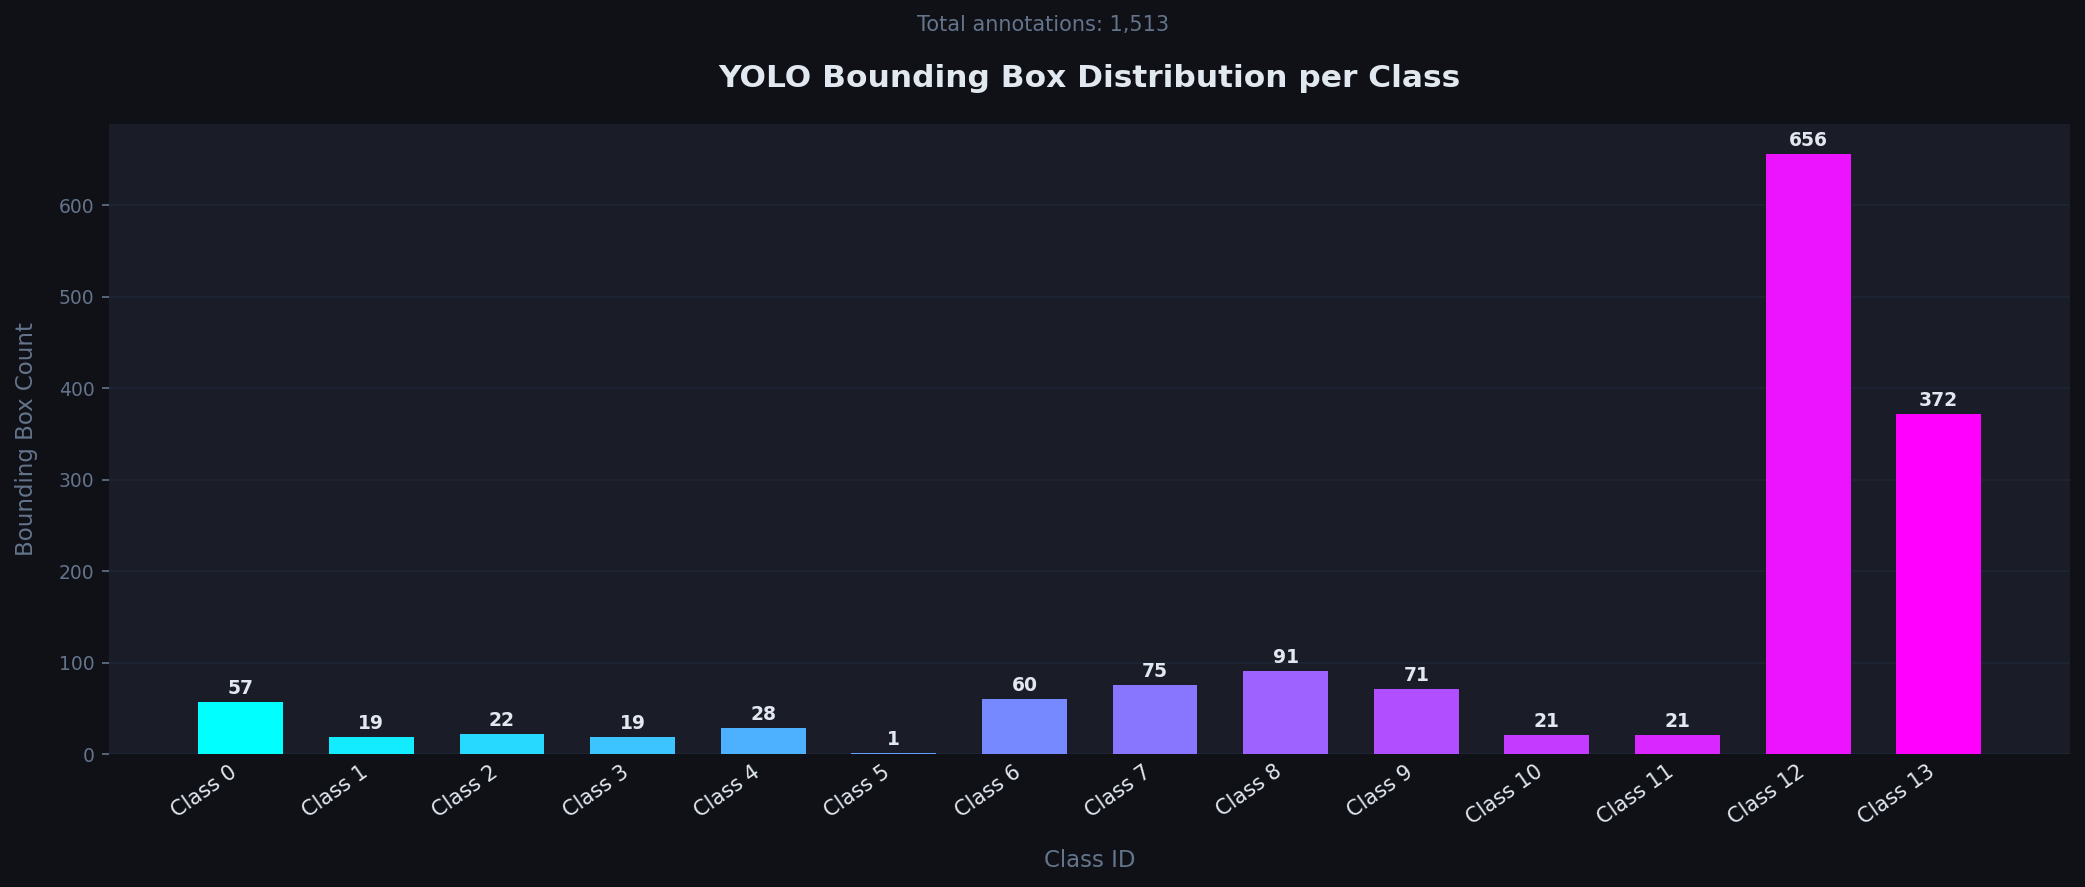


### Val subset

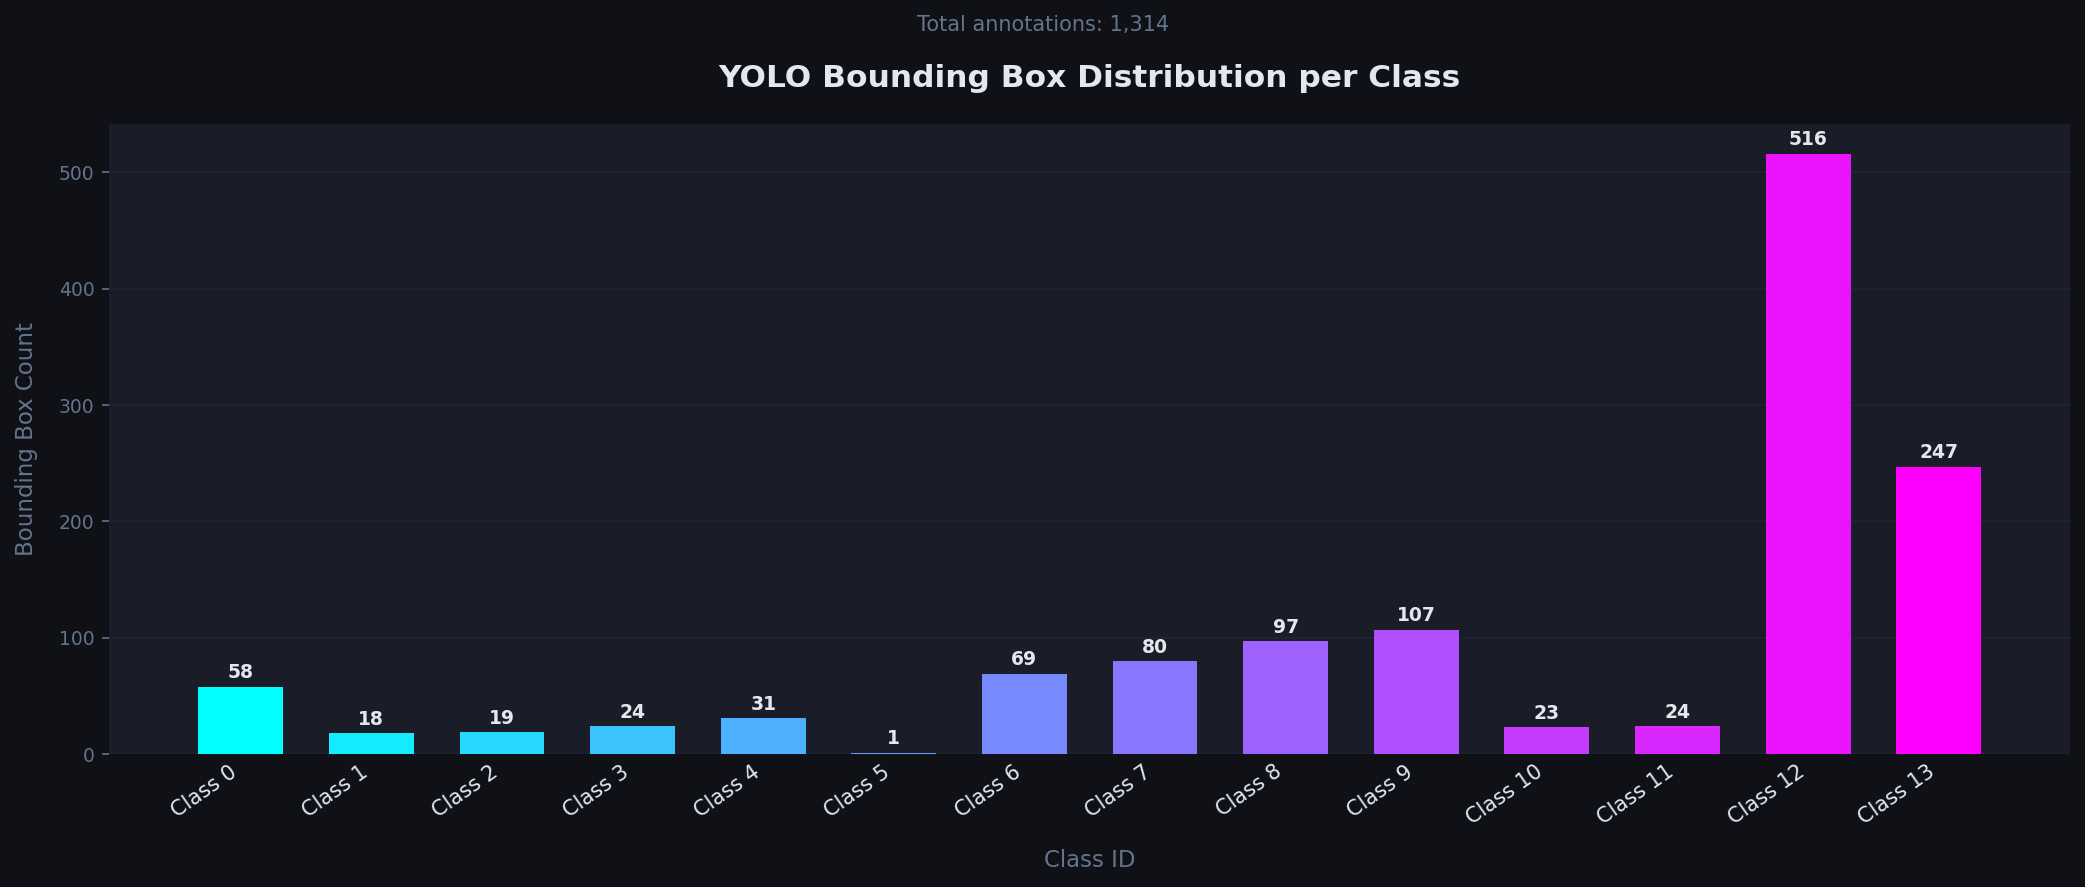

### Train subset

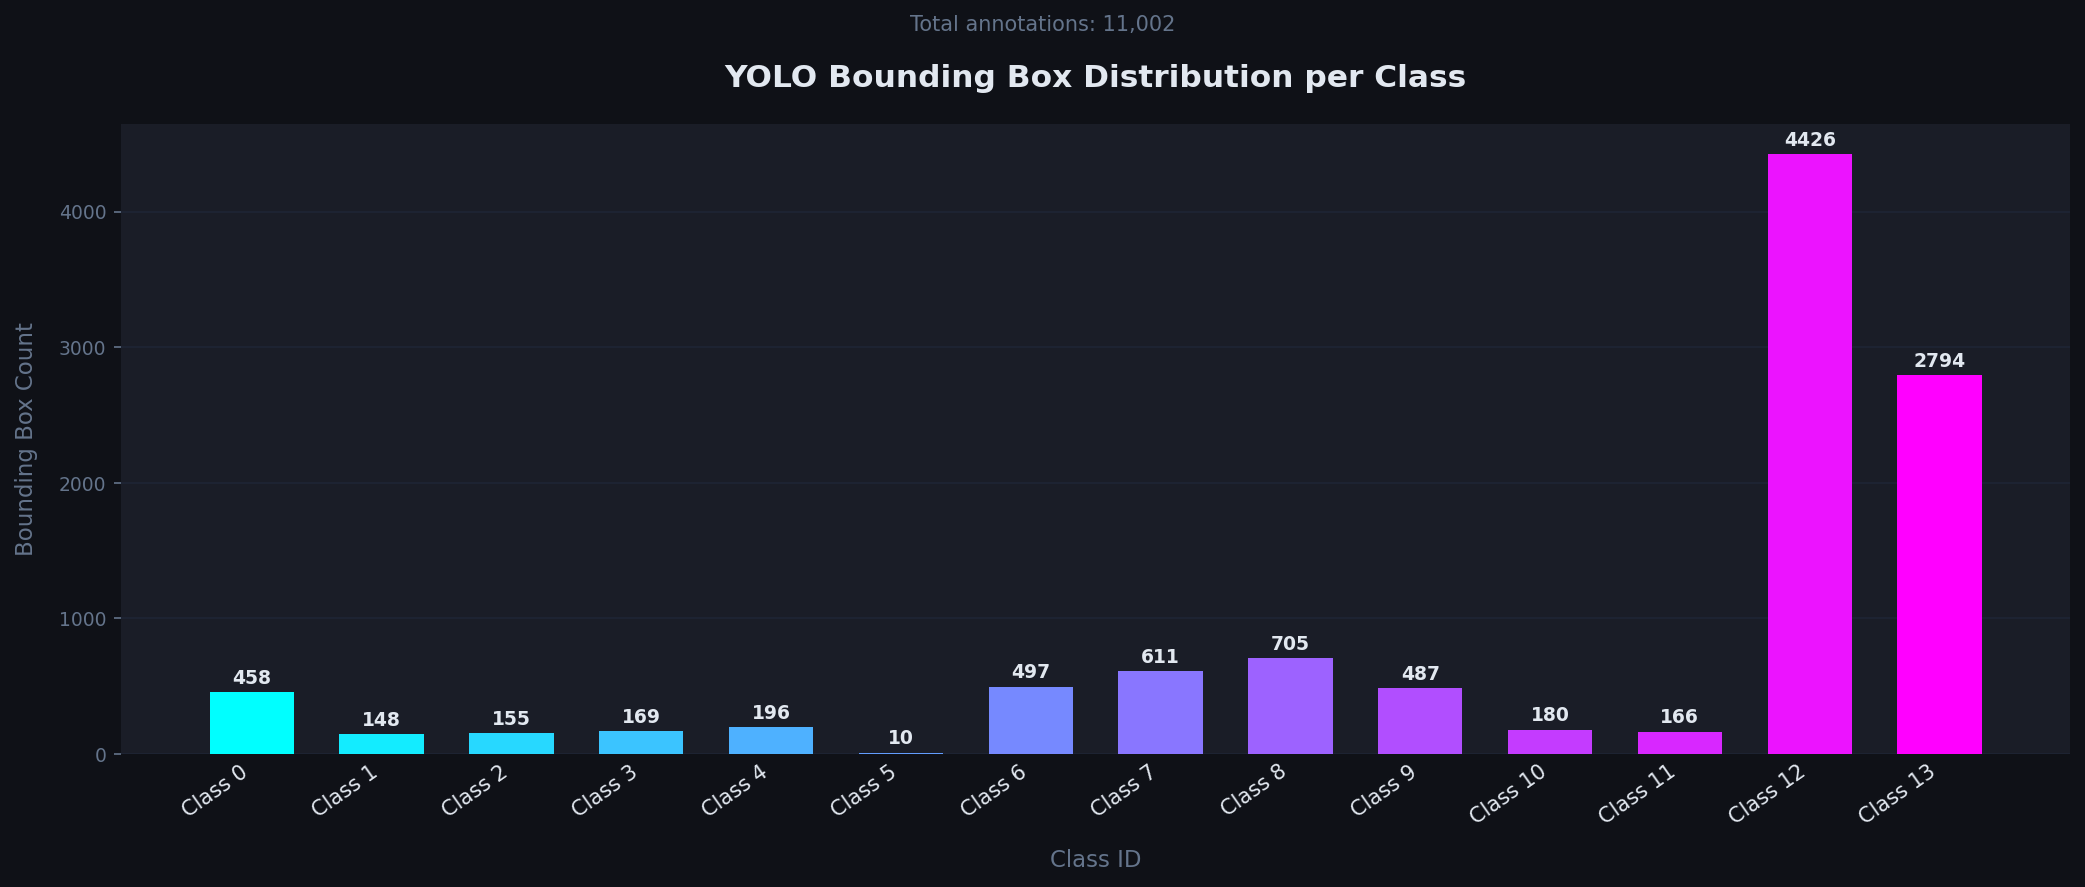

----images analysis----

Doing a 80/10/10 split on classes, we can see that all the 3 subsets share similar histograms.

One thing that is noticeable from the first glance is that classes 12 and 13 have much more bounding boxes. This is because these 2 classes come from the second dataset (progetto_dinale), which had not only more bounding boxes per image (dandelions and daisies many times appeared many in an image), but also many more samples.

Also, we can see that class 5 is highly unrepresented & classes 1, 2, 3, 10 and 11 could use some augmentations.

----images analysis----

Analyze object sizes. Compute bounding box width, height, and area (both absolute and relative to
image size) and visualize their distributions using histograms. This allows you to understand whether
most flowers are small, medium, or large within the image.

We did this using "bbox_size_analysis.py" in every subdirectory of the dataset. We will insert the resulted images here, for simplicity.

----images analysis----

### Test subset

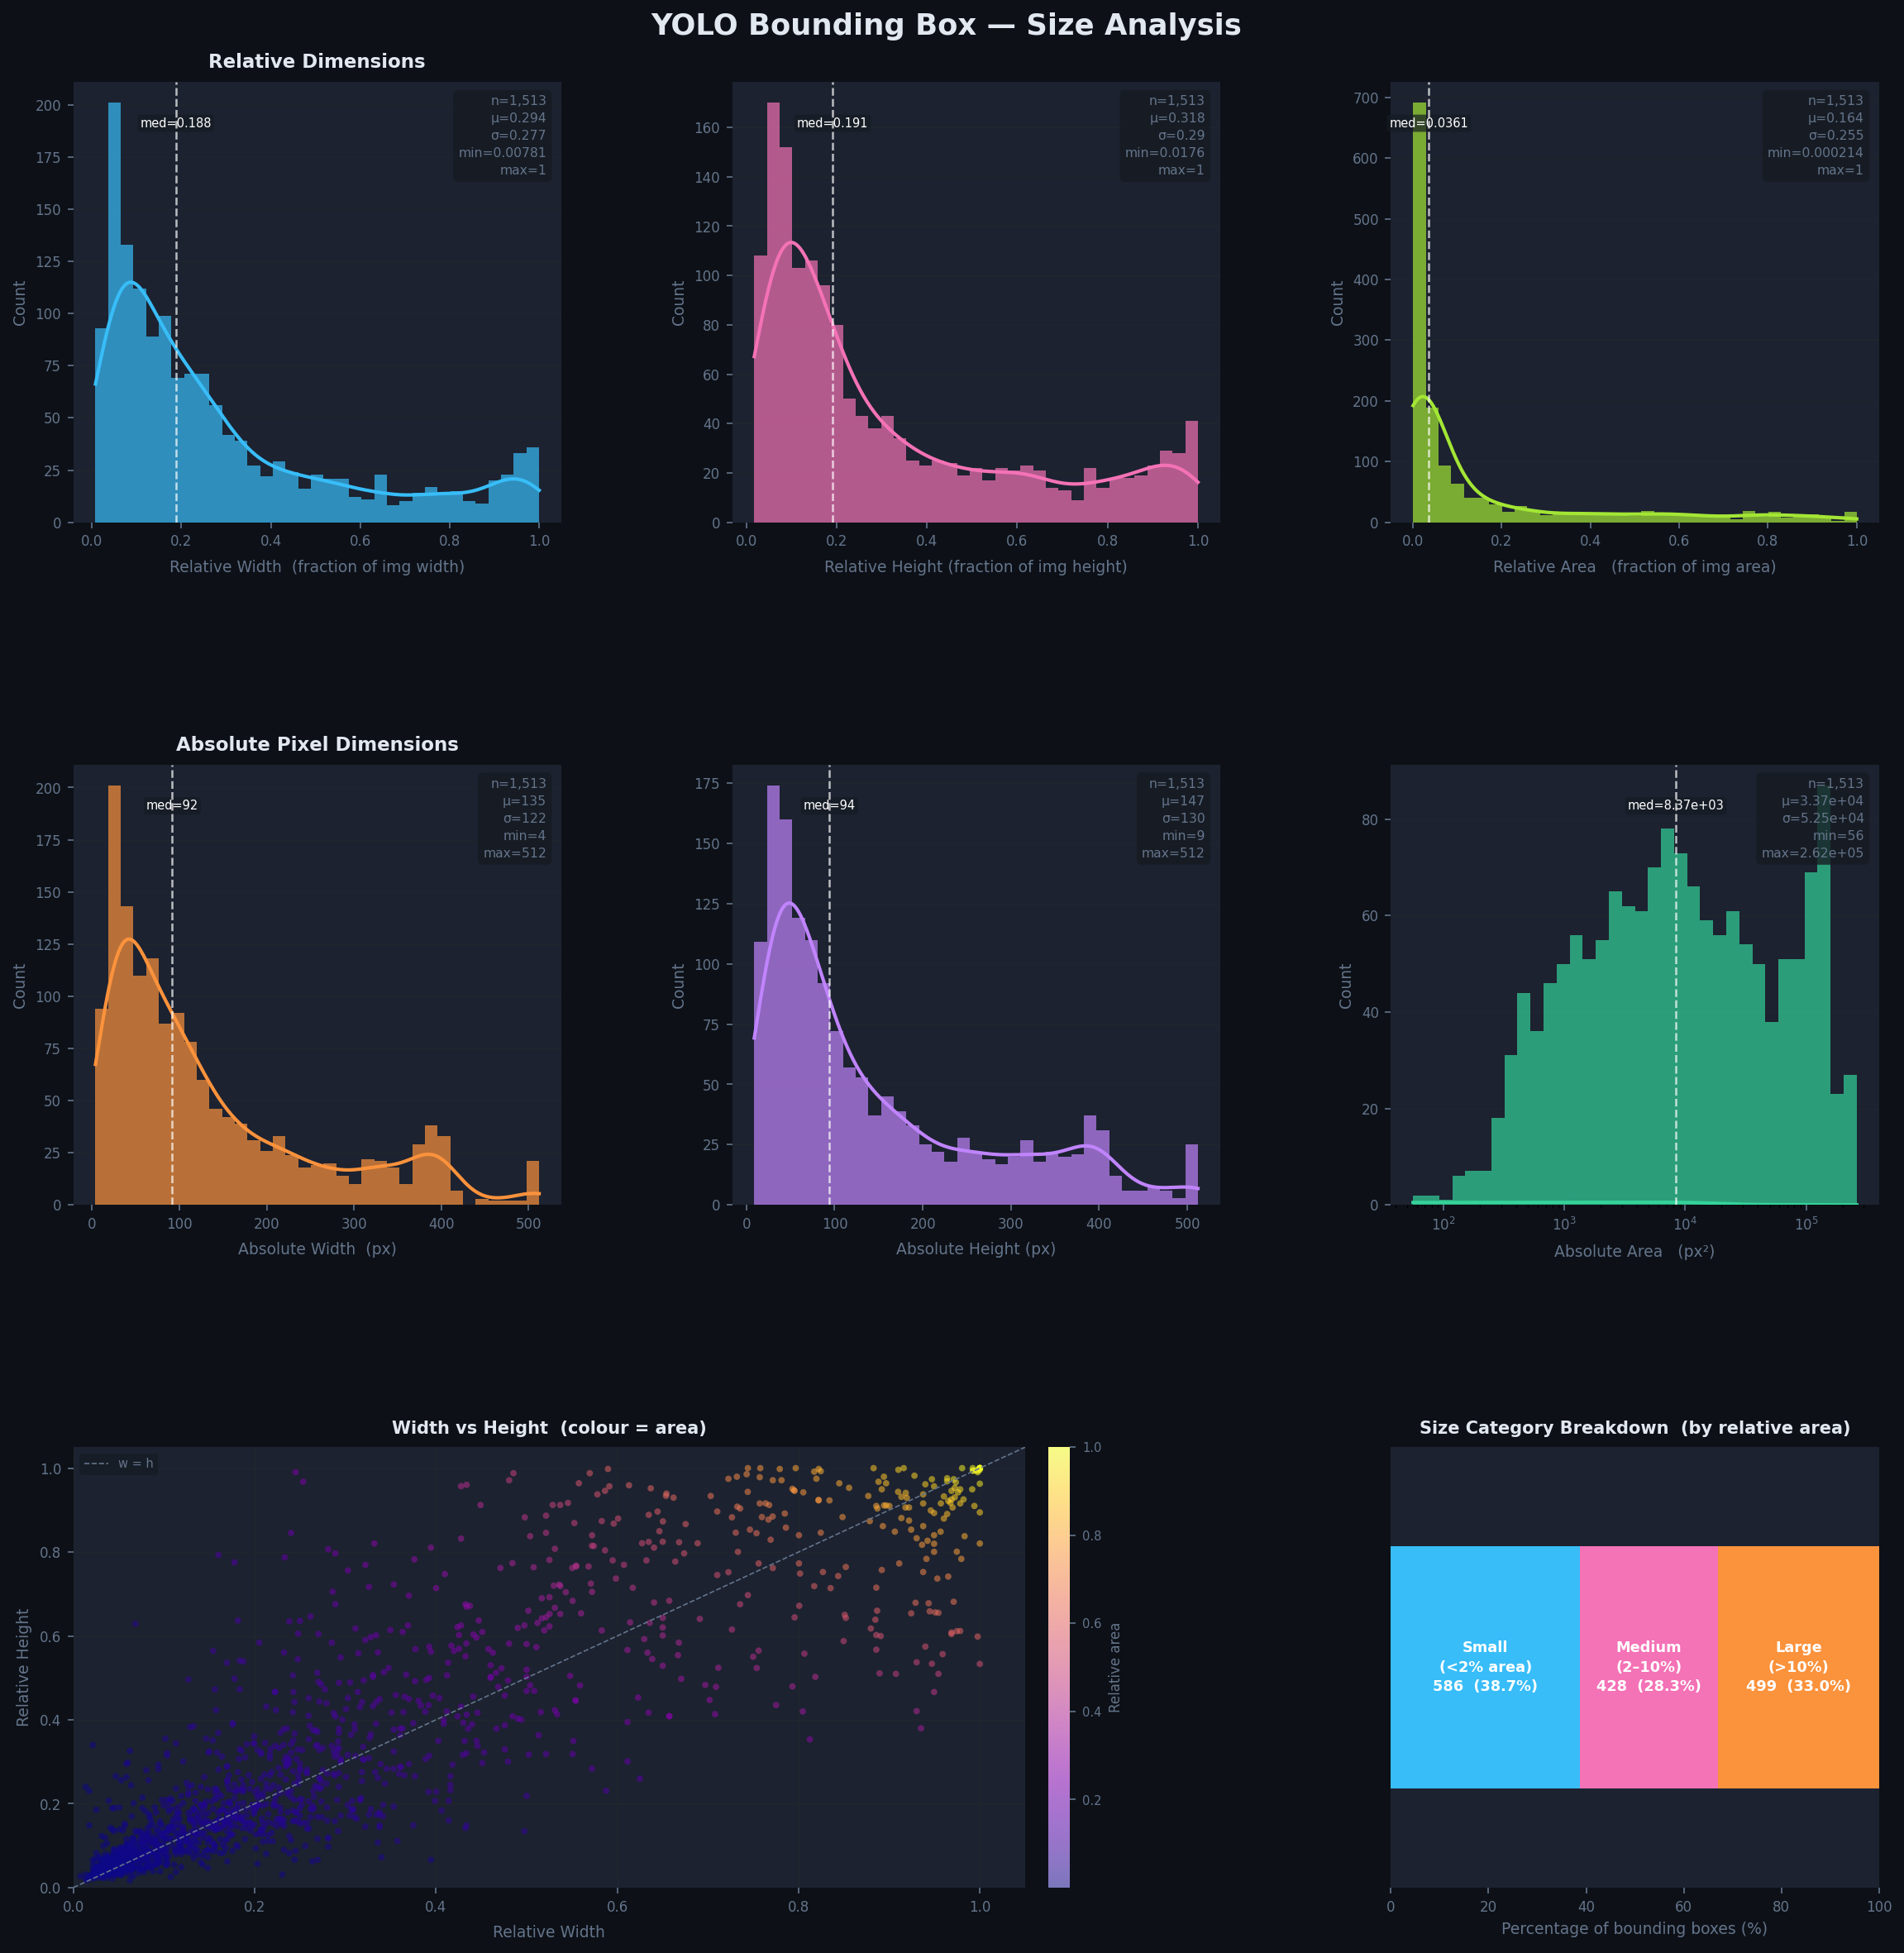

### Val subset

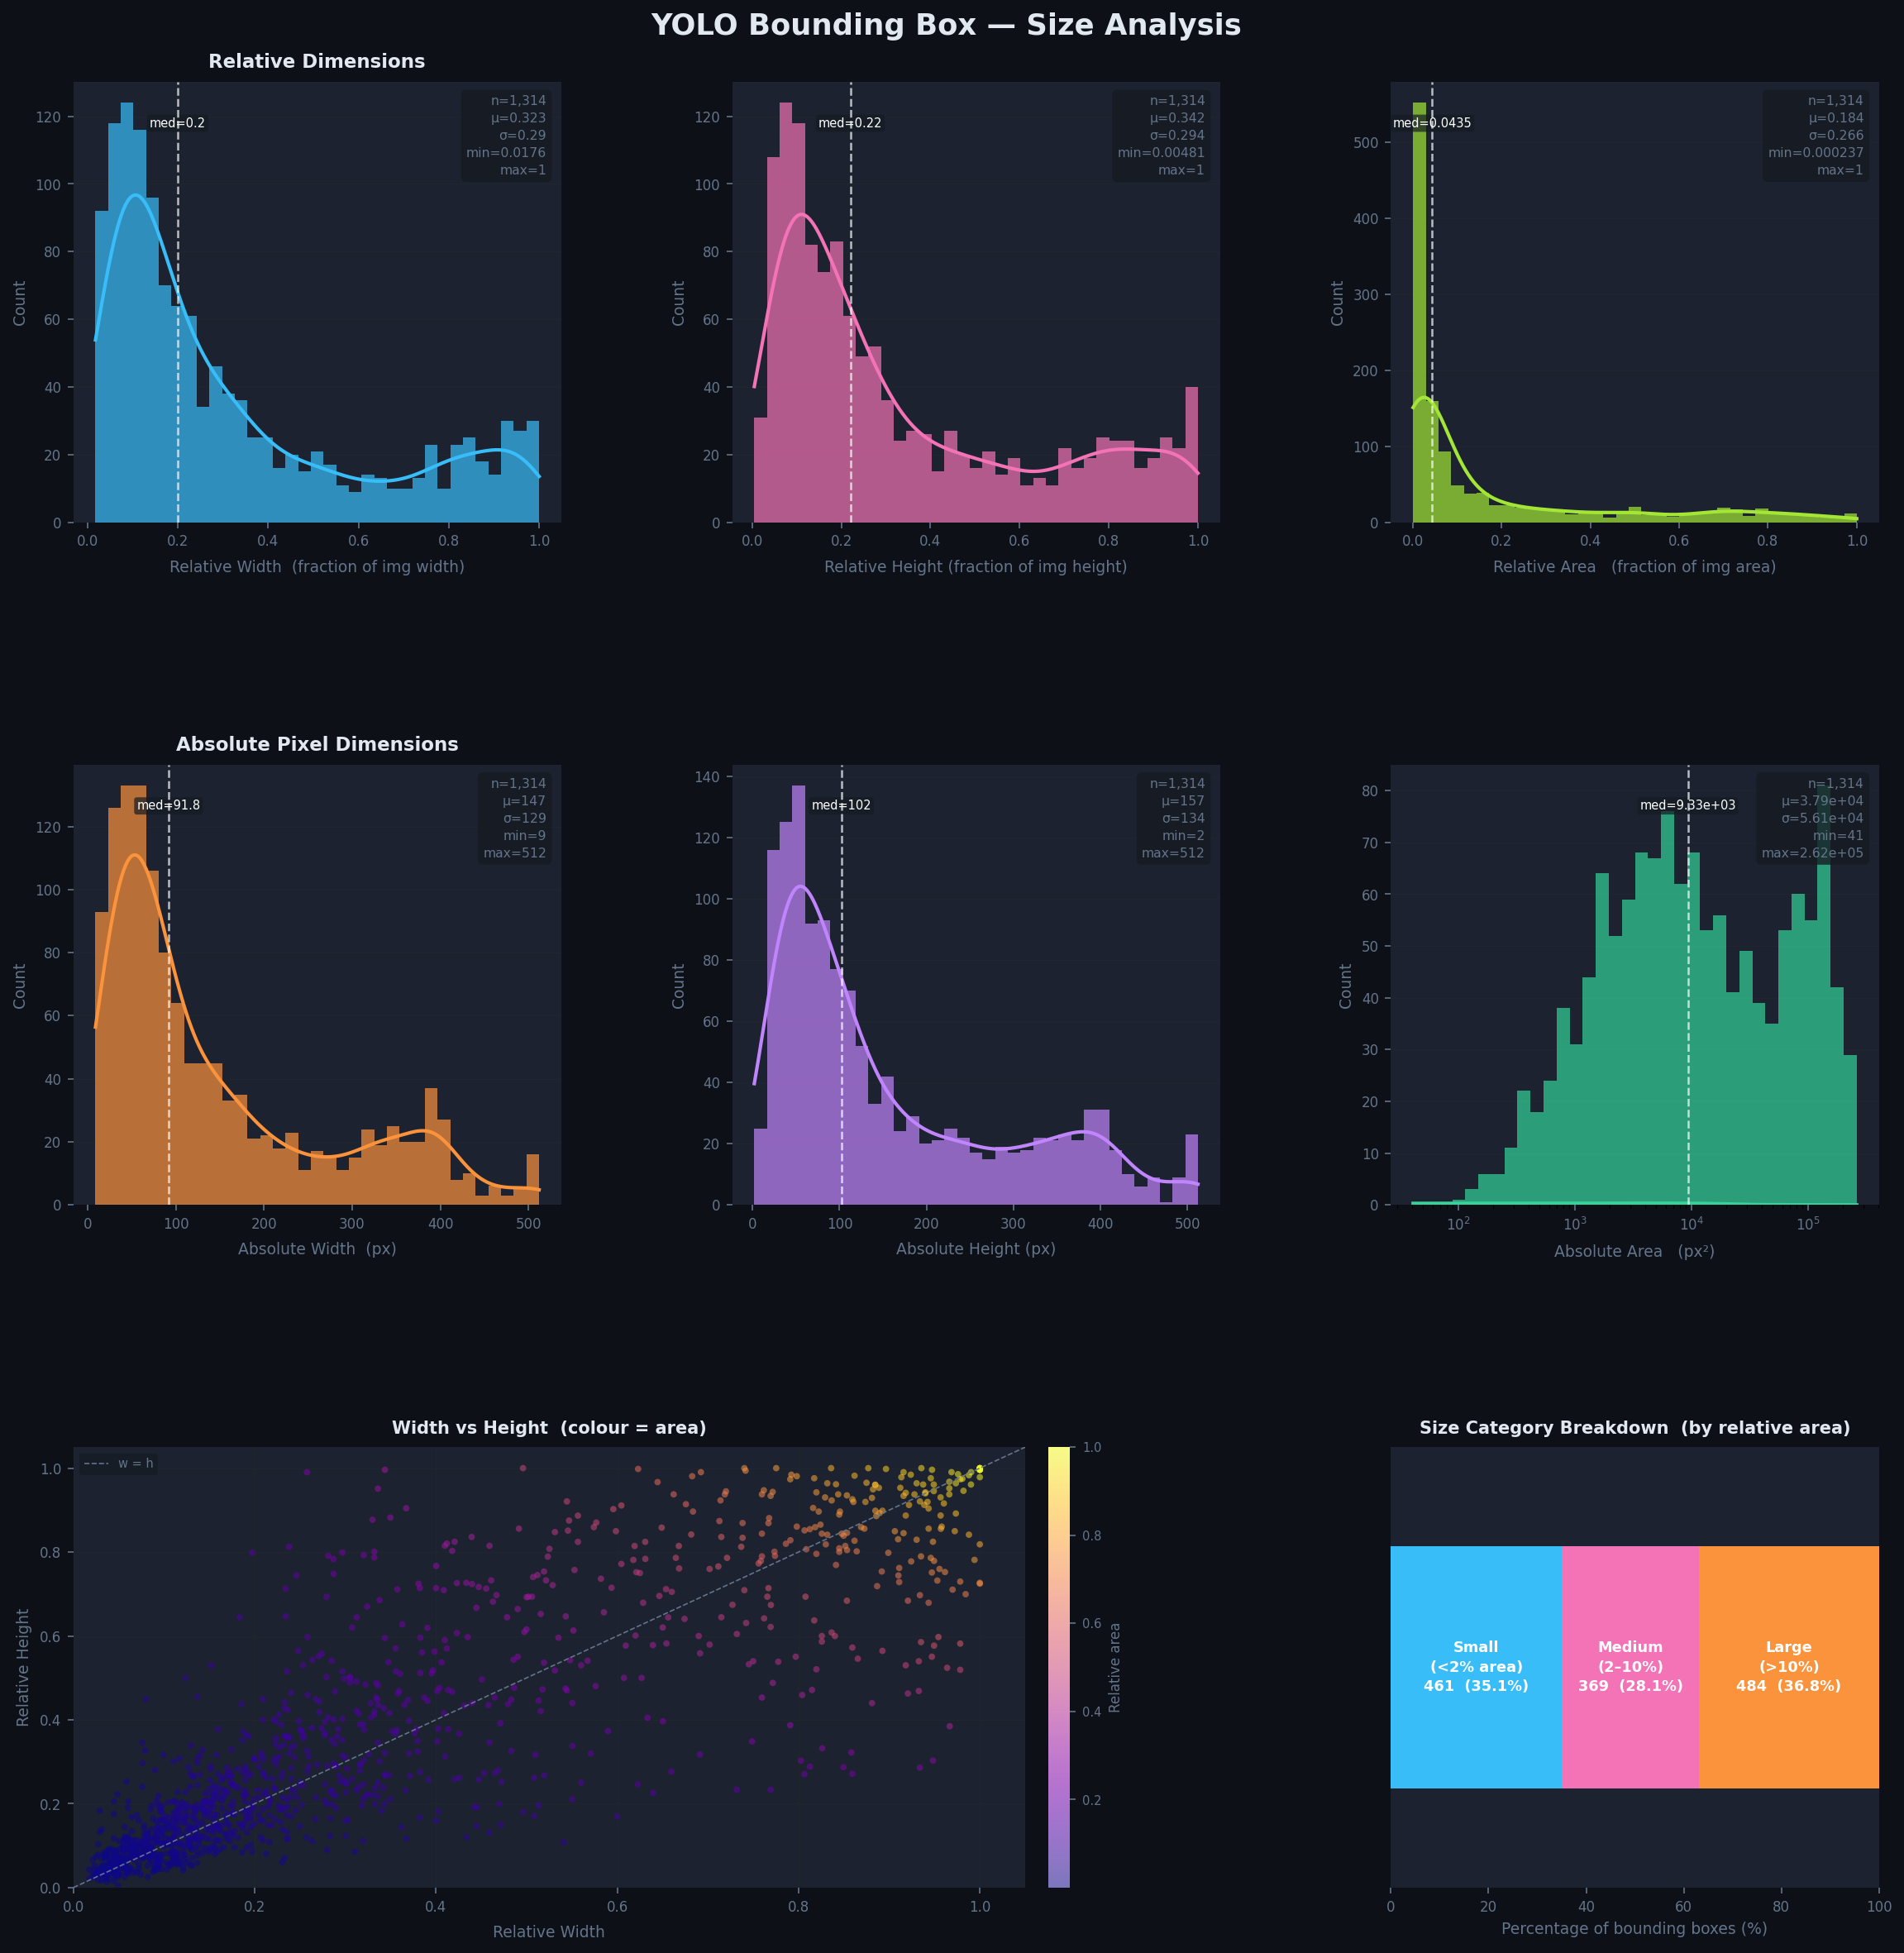

### Train subset

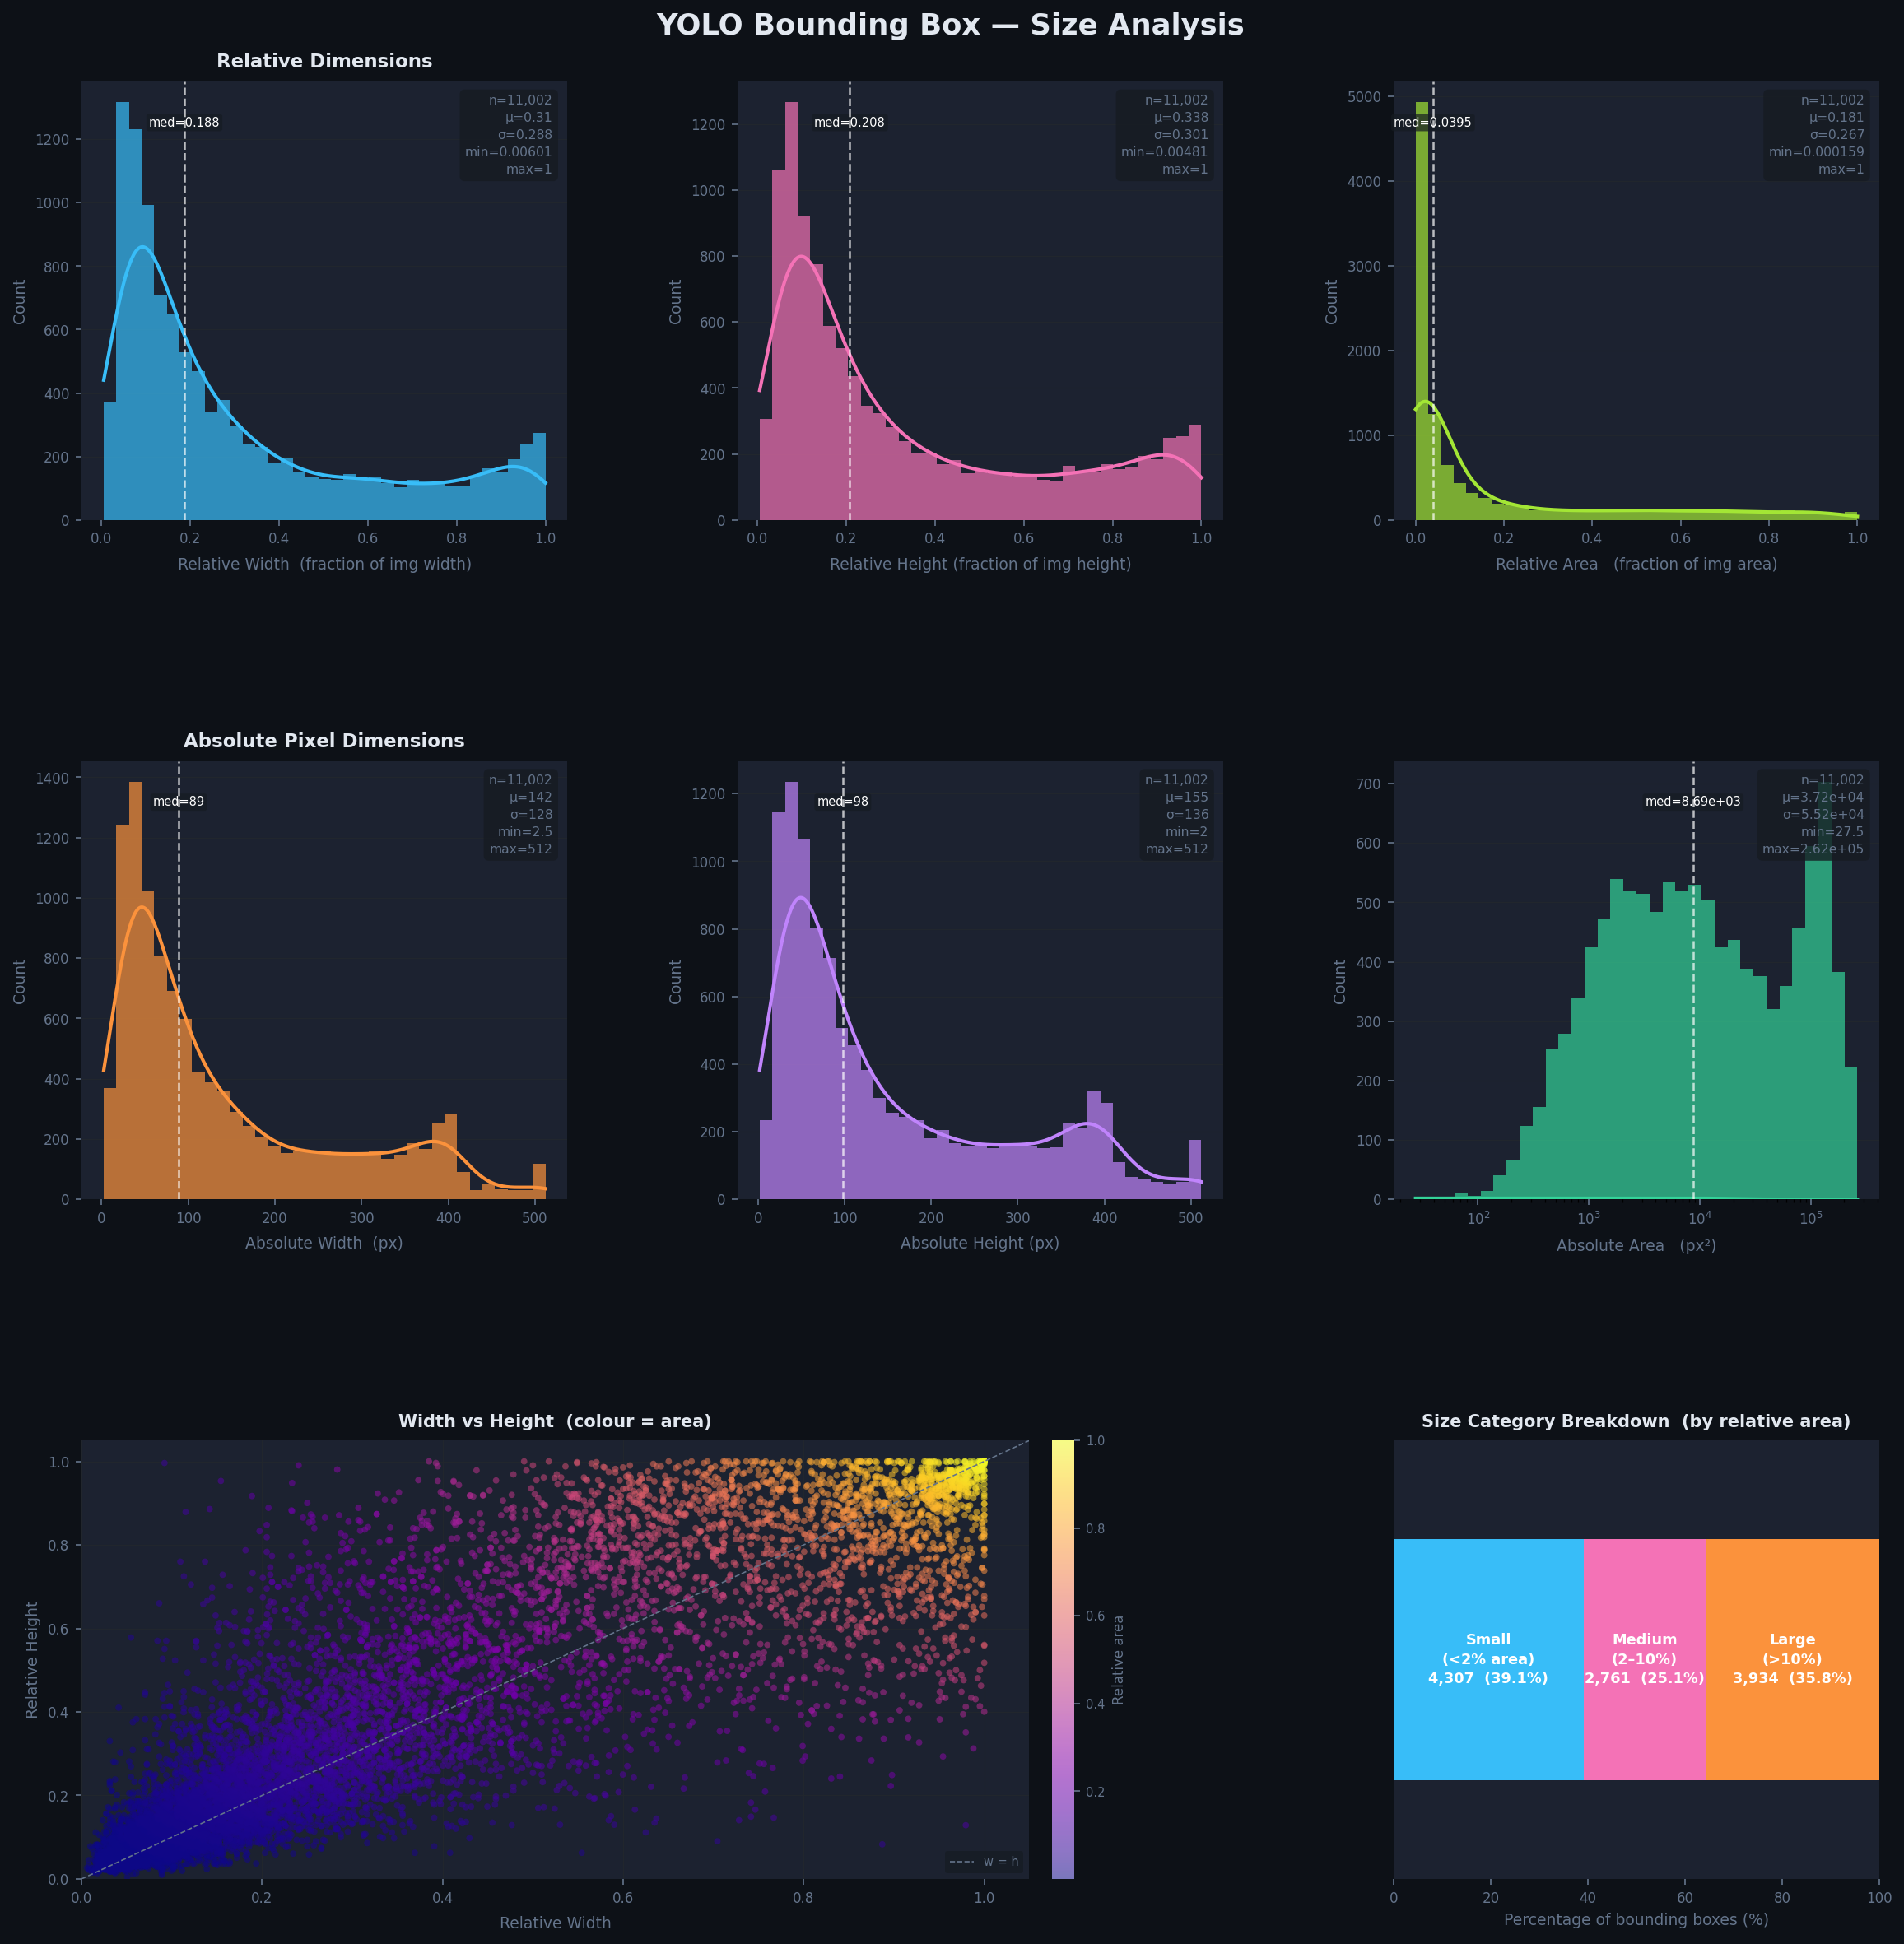

Again, having done a 80/10/10 split on classes, we can see that all the 3 subsets share similar histograms.

Having many daisies and dandelions (classes 12 and 13), which appear many in an image and having small area, we can see that the histrograms of relative width, height and area show that most of the flowers are small. However, most of the remaining classes have big flowers, that is why the relative width & height are close to 1 for considerably many images. Subsequently, the relative sizes are highly influenced by the class imbalance and the small flower sizes the preponderent 12 & 13 classes introduce.
Analyzing the absolute sizes, they reflect the same aspects.

Looking at width vs height graphic, we can see that they are quite balanced, because flowers are generally round, some differences coming from stems or leafes, which of course introduce higher width in contrast with height and viceversa.

Finally, the size category breakdown report summarizes our findings, i.e. that most of the flowers of the dataset are small, but this comes from classes imbalance. Moreover, medium and large flowers appear also, having a bit more large flowers in comparison with medium-size flowers.

# Object detection models


Now that you understand the evaluation metrics and you cleaned and processed the data, it is time to train
object detection models. In this laboratory, you will work with two state-of-the-art detectors (as of 2025):
YOLOv26 and RF-DETR. During the lectures, we discussed the YOLO family of models and the DETR line
of object detectors, but not these specific architectures.

Before training anything, your first task is to study the original papers of YOLOv26 and RF-DETR and
understand their architectures at a high level. You can consult additional resources such as blog posts or
explanatory videos, but you should not skip reading the papers themselves. Do not memorize implementation
details, but try to understand the design principles behind each model.

Analyze the experimental results reported in the papers. Identify the scenarios in which each model excels and
the cases where it struggles, such as small objects, crowded scenes, or computational constraints.

Finally, compare the two models in terms of computational complexity. Consider training cost, inference
latency, and hardware requirements. This analysis will help you reason about which model is more suitable for
different real-world applications.

For training you will use the repo/pip packages of these models, you don’t have to write any code.

# !!! In what follows, we will compare the experiments on the COCO dataset, as it appears in both of the papers and we can compare the models easily this way.

## YOLO26

- architectural design summary: it has a convolution-based archtectures, being able to capture complex features through many convolutional layers, at the beginning. Through multi-sclae feature maps, it manages to preserve semantic richness for both large and small objects.

Unlike previous YOLO variants, it outputs bounding boxes and class probabilities without relying on NMS. It uses ProgLoss and STAL + MuSGD.

- strengths: it makes bounding box prediction a more straight-forward regression task without sacrifying performance, removing Distribution Focal Loss. This makes YOLO26 hardware-friendly and more leightweight.

Another optimization is related to ProgLoss + STAL, which ensure training stability and small-object detection (similar to how Focal Loss works, but more efficient). ProgLoss dynamically adjusts the weighting of different loss components during training, ensuring that the model does
not overfit to dominant object categories while underperforming on rare or small classes. This progressive rebalancing
improves generalization and prevents instability during later epochs of training. STAL, on the other hand, explicitly
prioritizes label assignments for small objects, which are particularly difficult to detect due to their limited pixel
representation and susceptibility to occlusion.

MuSGD uses Stochastic Gradient Descent and Muon optimizer (technique inspired by LLM optimization strategies). This way, training is stable and the model converges faster during training.

All these optimizations + the fact that the model looks at the images only once + the Ultralytic real-time deployment integration makes the model flexible, easy to integrate, easy to quantizate and to use on resource-constrainted devices. Also, it ensures that the model is cross-industry.

- weaknesses: limited task coverage, could improve through multi-task versatility.

Lack of semi-supervised or self-supervised learning, every time you use it you have to train it from scratch. A future YOLO might automatically leverage vast amounts of
unannotated images or videos to improve recognition robustness. By doing so, the model can continue to improve its
detection capabilities without proportional increases in labeled data, making it more adaptable to new domains or rare
object categories.



- computational complexity: very low, having a good latency.

The experiments show that even small variants of YOLO26 (with nr of parameters = 2.4 or 9.5) still offer comparative and competitive performance with larger variants. The Speed regarding CPU ONNX and T4 TRT10 is also good, making it extremely efficient in robotic or any real-time application. This aspect of hardware efficiency is also mentioned in the official paper.

While YOLO26 evolved from the previous variants through emphasizing small object detection, training stability & convergence and hardware efficiency,  it may still struggle on datasets with crowded scenes, or with domain shifts & adverse conditions (rain, fog etc).


## RD-DETR

- architectural design summary: ViT-based architecture, uses a pre-trained vit backbone to extract image features. Also, it makes use of attention blocks and bilinear interpolation on the output of the projectors, ensuring consistent spatial organization.

- strengths: RF-DETR is the first real-time detector to exceed 60 mAP on COCO, achieving 60.5% at 25 FPS on a T4 GPU. Moreover, it converges quickly (under 20 epochs) and runs fast. Also, being based on ViT, it has a good domain generalization, generally being able to detect objects better from crowded scenes or more complicated environments.

An optimization mentioned in the paper is dropping the decoder during inference time, which of course is an advantage.

- weaknesses: On CPU-only or severely memory-constrained edge hardware, RF-DETR's resource requirements can be prohibitive at larger model sizes. YOLO's speed advantage is real in this narrow context.

RF-DETR will require more epochs and layers to converge than YOLO when training from scratch, though pretrained models and compatibility with vision transformers for transfer learning help mitigate this.

- computational complexity:

The transformer encoder-decoder structure introduces overhead on first inference that can be noticeable in latency-sensitive deployments, requiring model warming strategies in production.


Analyzing the results, we can see that the bigger variant (2XL) of RF-DETR obtains over 60% AP, but of course with the cost of hardware consumption. The small variant, with ~34M parameters, offers comparable results with YOLO26, but with a better latency. The problem is that the number of parameters is bigger and the hardware constraints could not permit such a model to fit on smaller devices.


### Conclusion:

RF-DETR wins on accuracy and generalization, especially on GPUs. YOLO26 wins on edge deployability, hardware compatibility, and ecosystem maturity. RF-DETR NAS is faster and more accurate than YOLO26 in head-to-head benchmarks, but for many real-world deployments, particularly on constrained hardware, YOLO26 remains the more practical choice.

## Training YOLO26 using our ORIGINAL DATA

In [1]:
import torch
if torch.cuda.is_available():
    !nvidia-smi
else:
    print("NO GPU :( )")

Sat May  9 17:55:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import requests
from io import BytesIO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Training RF-DETR using our ORIGINAL DATA

# Generating synthetic data

One experiment that you will perform in this laboratory is to generate synthetic data and evaluate whether
adding it to your training set improves detection performance. Synthetic data here means new images with
automatically generated annotations, not just simple augmentations of existing ones. You can try any of the
following or propose a completely new pipeline:

- Copy-Paste Composition: Extract flower instances (using their bounding boxes or segmentation
masks if available or use SAM) and paste them onto different background images to create new
scenes. Vary placement, scale, and orientation to make these composites realistic. This does not
require expensive modeling or generative training.

- Diffusion inpainting for background replacement. Keep the flower region fixed (mask it), and use
inpainting to generate different plausible backgrounds around it: different vegetation, lighting feel,
clutter, seasonal colors, etc.

## Training YOLO26 using our SYNTHETIC DATA

## Training RF-DETR using our SYNTHETIC DATA